# Automobiles price prediction
## Title: 1985 Auto Imports Database

# Step.1 Problem Definition

The objective of this project is to analyze the automobile dataset and build a machine learning model to predict car prices based on various independent
variables such as engine size, horsepower, fuel type, and other specifications.

The goal is to help the business understand how different features affect the price of a car so that they can make better decisions regarding product
design and pricing strategy.

This is a supervised learning problem and specifically a regression task since the target variable (price) is continuous.

#### Some important variables (columns) :-
###### These variables were selected based on their expected impact on car pricing.
###### price: Target variable representing the cost of the car
###### engine-size: Size of engine, major factor affecting price
###### horsepower: Power of engine, directly impacts performance and price
###### curb-weight: Weight of the car, influences price
###### fuel-type: Type of fuel (gas/diesel)

# Step.2 Data Collection

The dataset used for this project was obtained from the provided source link. It contains automobile-related information such as engine specifications,
fuel type, dimensions, and pricing details.

The dataset was downloaded in a compressed (ZIP) format and extracted locally. The primary file used for analysis is:

auto_imports.csv – contains the actual data used for modeling
auto_imports_names.txt – contains attribute information and column descriptions

The dataset consists of multiple features (independent variables) and one target variable (price), which is used for prediction.

The data was loaded into a Jupyter Notebook environment using the pandas library for further analysis and preprocessing.

In [2]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

In [3]:
# # load dataset
# import auto_imports.csv
df=pd.read_csv("auto_imports.csv")

In [4]:
df

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
196,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
197,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
198,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [5]:
# The dataset does not contain column headers, so column names were assigned manually using the provided attribute information file.

col_names = ["symboling","normalized-losses","make","fuel-type","aspiration",
             "num-of-doors","body-style","drive-wheels","engine-location",
             "wheel-base","length","width","height","curb-weight","engine-type",
             "num-of-cylinders","engine-size","fuel-system","bore","stroke",
             "compression-ratio","horsepower","peak-rpm","city-mpg",
             "highway-mpg","price"]

df = pd.read_csv("auto_imports.csv", names=col_names)

In [6]:
df

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


# Step.3 Data Preprocessing

In this step, the data is cleaned by handling missing values and converting it into a proper format for analysis.

In [7]:
# BASIC CHECKS :- Basic checks were performed to understand the structure, data types, and quality of the dataset before further preprocessing.
 
df.head() # show 1st 5 rows of dataset

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [8]:
df.tail()  # show last 5 rows 

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470
200,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625


In [9]:
df.shape    # Total rows and columns

(201, 26)

In [10]:
df.columns     # columns name

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [11]:
df.info()    # Check which columns are object, Which should be numeric but are object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       201 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [12]:
df.describe()     #statistical summary-mean, min, max, standard deviation, helps to detect outliers .

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,10.164279,25.179104,30.686567,13207.129353
std,1.254802,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,4.004965,6.423220,6.815150,7947.066342
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,8.600000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,9.400000,30.000000,34.000000,16500.000000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [13]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# The most important observation in my dataset is there is not any empty or null but '?' present.
# Replace "?" with NaN
#The dataset contains missing values represented by '?', which were replaced with NaN for proper handling.

df.replace("?", np.nan, inplace=True)

In [16]:
df.head(4)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950


In [17]:
# Now, we will see actual missing value in this dataset.
df.isnull().sum()

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

In [18]:
# Before filling null value first we have to change datatype , columns are in object type but have to convert it into float datatype to enable proper analysis.
# Because machine learns models cannot work with text ,need numbers.

cols = ['normalized-losses','bore','stroke','horsepower','peak-rpm','price']

for col in cols:
    df[col] = df[col].astype(float)



In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               201 non-null    object 
 3   fuel-type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num-of-doors       199 non-null    object 
 6   body-style         201 non-null    object 
 7   drive-wheels       201 non-null    object 
 8   engine-location    201 non-null    object 
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    object 
 15  num-of-cylinders   201 non-null    object 
 16  engine-size        201 non

In [20]:
# Handle missing value
# Missing values in numerical columns were handled using mean imputation, while categorical columns were handled using mode imputation.

# Fill mean in numerical values

'''df['normalized-losses'].fillna(df['normalized-losses'].mean(), inplace=True)
df['bore'].fillna(df['bore'].mean(), inplace=True)
df['stroke'].fillna(df['stroke'].mean(), inplace=True)
df['horsepower'].fillna(df['horsepower'].mean(), inplace=True)
df['peak-rpm'].fillna(df['peak-rpm'].mean(), inplace=True)'''



df['normalized-losses'] = df['normalized-losses'].fillna(df['normalized-losses'].mean())
df['bore'] = df['bore'].fillna(df['bore'].mean())
df['stroke'] = df['stroke'].fillna(df['stroke'].mean())
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())
df['peak-rpm'] = df['peak-rpm'].fillna(df['peak-rpm'].mean())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

In [21]:
# Fill mode in categorical columns 
'''df['num-of-doors'].fillna(df['num-of-doors'].mode()[0], inplace=True)'''

df['num-of-doors']=df['num-of-doors'].fillna(df['num-of-doors'].mode())

In [22]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [23]:
# Encoding categorical values
# Models cannot understand text like: gas, sedan, fwd, so we convert them into numbers
# Categorical variables were converted into numerical format using One Hot Encoding

df = pd.get_dummies(df, drop_first=True)   # drop_first=True for avoid multicollinearity

In [24]:
df = df.astype(int)  # I converted into 0 and 1 . Otherwise it print True or False.

In [25]:
df

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,122,88,168,64,48,2548,130,3,2,...,0,0,0,0,0,0,0,1,0,0
1,3,122,88,168,64,48,2548,130,3,2,...,0,0,0,0,0,0,0,1,0,0
2,1,122,94,171,65,52,2823,152,2,3,...,0,0,0,0,0,0,0,1,0,0
3,2,164,99,176,66,54,2337,109,3,3,...,0,0,0,0,0,0,0,1,0,0
4,2,164,99,176,66,54,2824,136,3,3,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,109,188,68,55,2952,141,3,3,...,0,0,0,0,0,0,0,1,0,0
197,-1,95,109,188,68,55,3049,141,3,3,...,0,0,0,0,0,0,0,1,0,0
198,-1,95,109,188,68,55,3012,173,3,2,...,0,0,0,0,0,0,0,1,0,0
199,-1,95,109,188,68,55,3217,145,3,3,...,0,0,0,0,0,1,0,0,0,0


# Step.4 EDA (Exploratory Data Analysis)
Exploratory Data Analysis (EDA) performed to understand the relationships between features and the target variable.

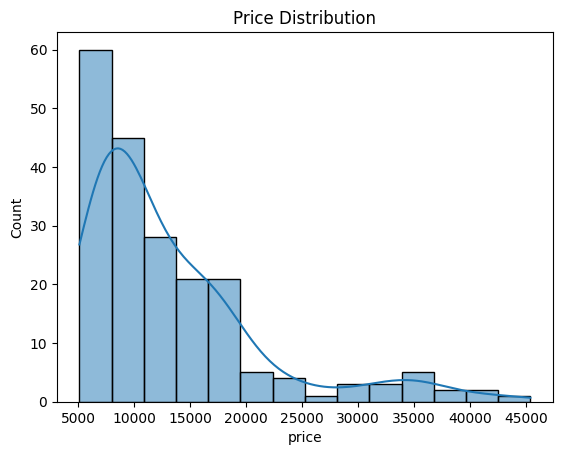

In [26]:
# Univariate Analysis (Single column) - 
#Price Distribution

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

#Price is skewed / normal, Most cars fall in range

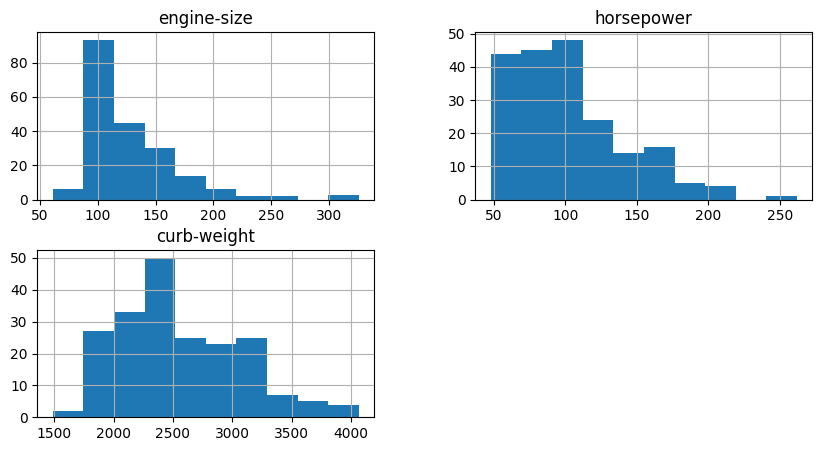

In [27]:
# Numerical features distribution

df[['engine-size','horsepower','curb-weight']].hist(figsize=(10,5))
plt.show()

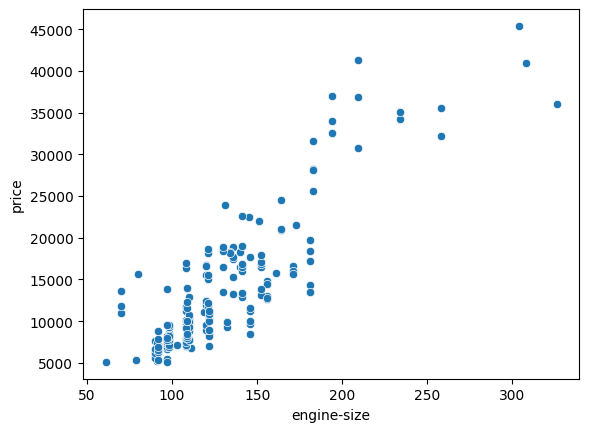

In [28]:
# Bivarient analysis
#Engine Size vs Price

sns.scatterplot(x='engine-size', y='price', data=df)
plt.show()

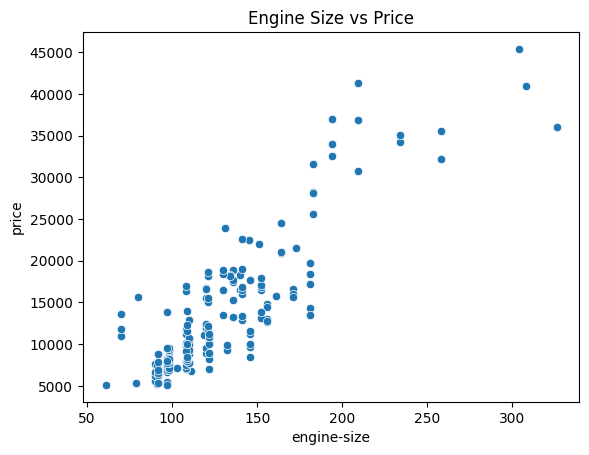

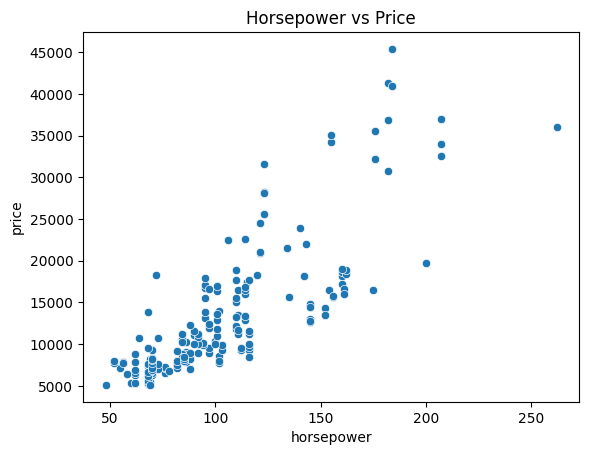

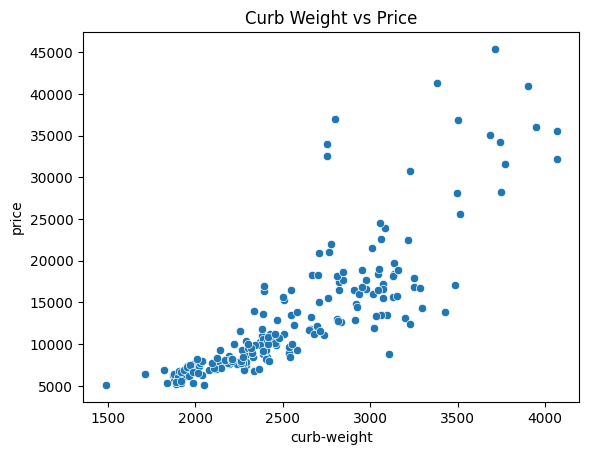

In [29]:
sns.scatterplot(x='engine-size', y='price', data=df)
plt.title("Engine Size vs Price")
plt.show()

sns.scatterplot(x='horsepower', y='price', data=df)
plt.title("Horsepower vs Price")
plt.show()

sns.scatterplot(x='curb-weight', y='price', data=df)
plt.title("Curb Weight vs Price")
plt.show()

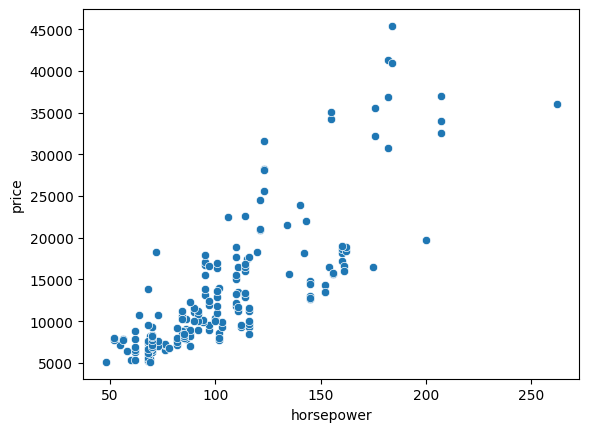

In [30]:
# Horsepower vs Price

sns.scatterplot(x='horsepower', y='price', data=df)
plt.show()

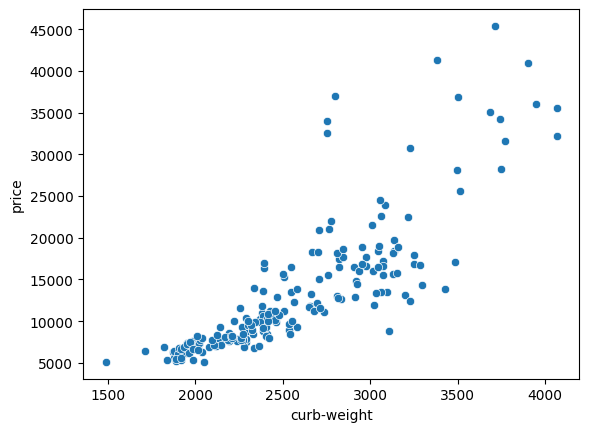

In [31]:
# Curb weight vs Price

sns.scatterplot(x='curb-weight', y='price', data=df)
plt.show()

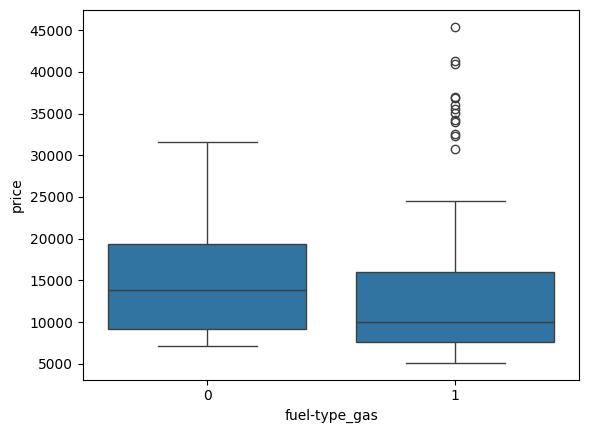

In [32]:
# Categorical vs Price - fuel type

sns.boxplot(x='fuel-type_gas', y='price', data=df)
plt.show()

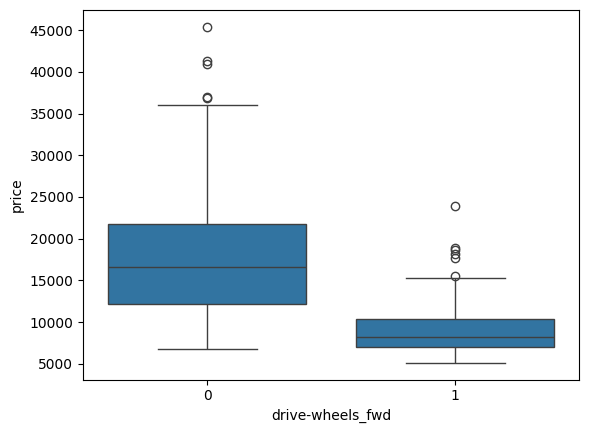

In [33]:
# Drive wheels

sns.boxplot(x='drive-wheels_fwd', y='price', data=df)
plt.show()

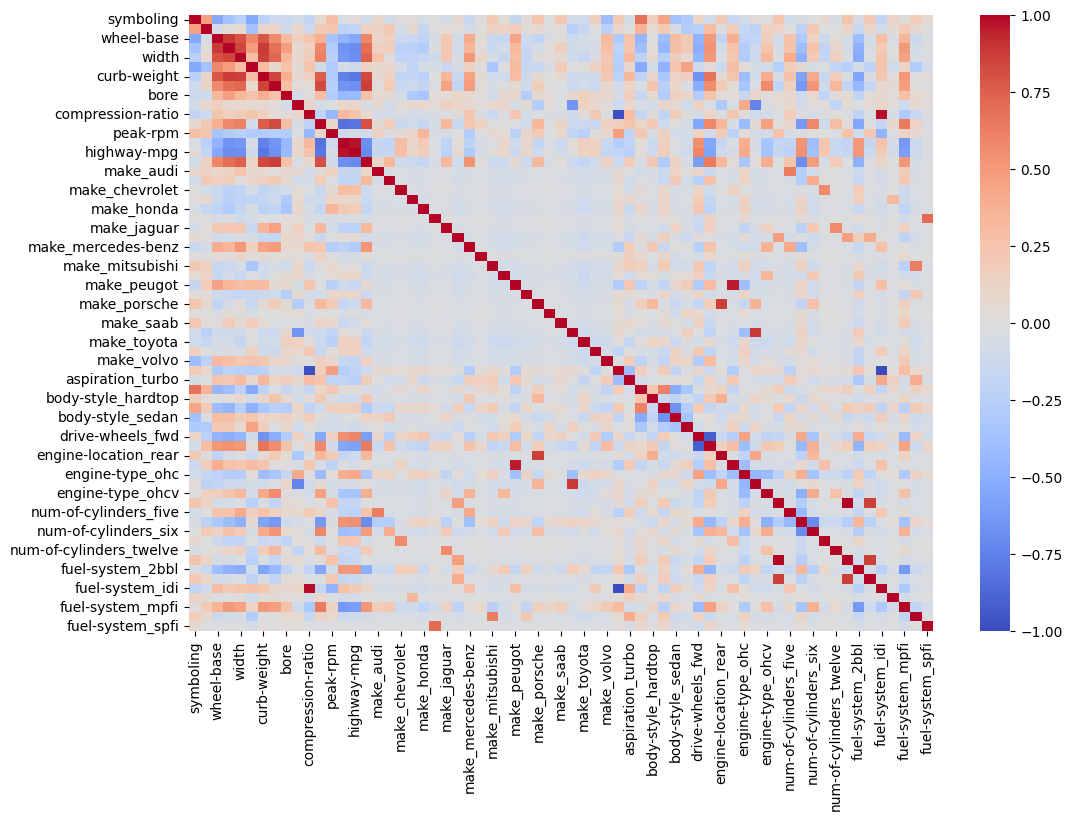

In [34]:
# Correlation heatmap
#focus on - Features strongly related to price

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

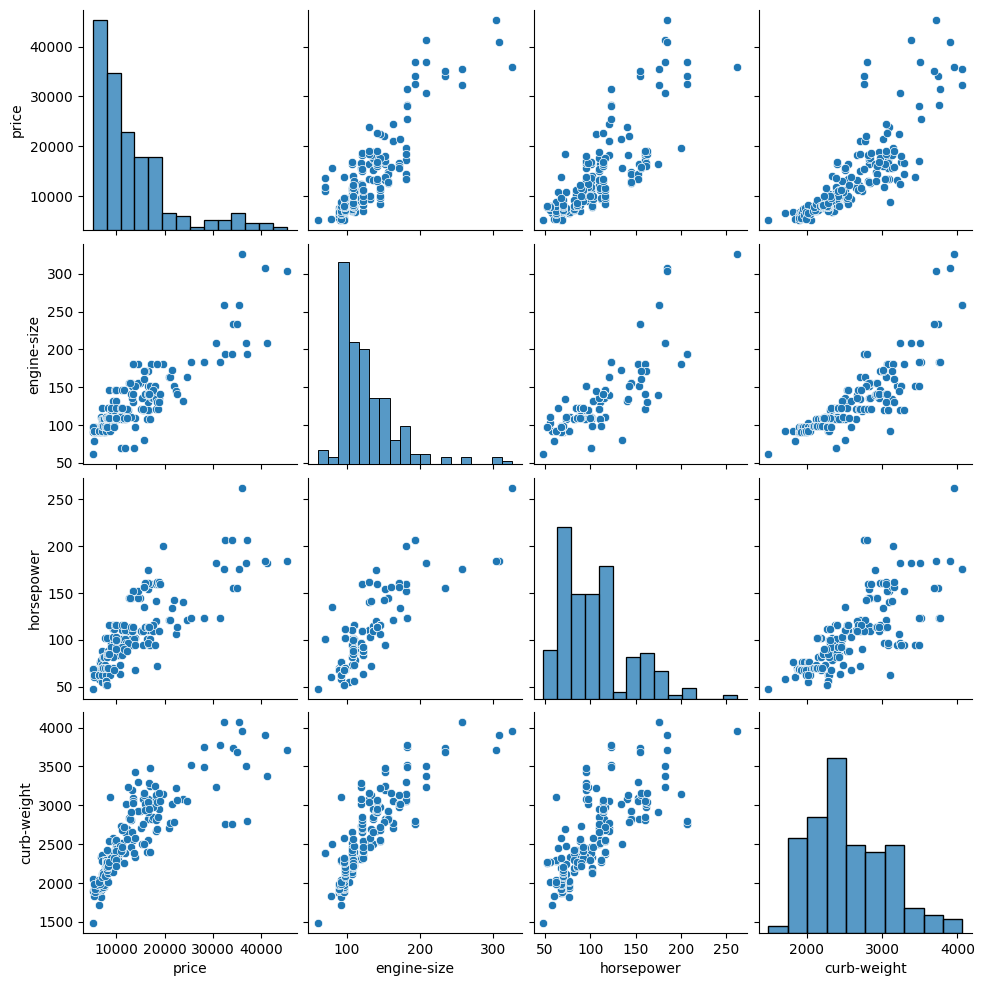

In [35]:
# Pairplot -Relationship between all features. We can see overall pattern between variables, linear relationships.S

sns.pairplot(df[['price','engine-size','horsepower','curb-weight']])
plt.show()

In [36]:
#HOW to find which feature is most related to price
#Relationship of every feature with price

df.corr()['price'].sort_values(ascending=False)

price                    1.000000
engine-size              0.872335
curb-weight              0.834415
horsepower               0.809729
width                    0.746032
                           ...   
fuel-system_2bbl        -0.497825
drive-wheels_fwd        -0.595979
city-mpg                -0.686571
num-of-cylinders_four   -0.691968
highway-mpg             -0.704692
Name: price, Length: 65, dtype: float64

<Axes: xlabel='engine-size', ylabel='price'>

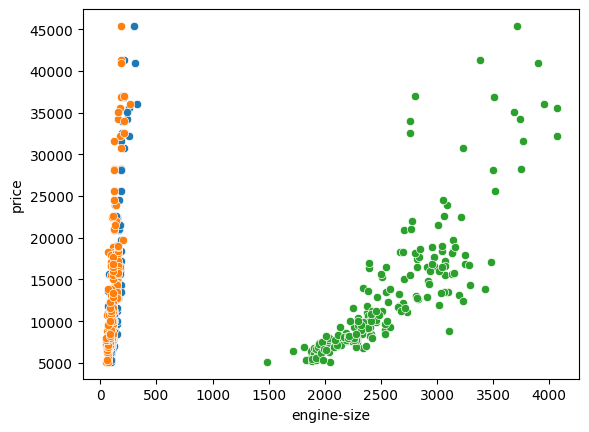

In [37]:
# Scatter plot - visually prove your correlation

sns.scatterplot(x='engine-size', y='price', data=df)
sns.scatterplot(x='horsepower', y='price', data=df)
sns.scatterplot(x='curb-weight', y='price', data=df)

<Axes: xlabel='price', ylabel='Count'>

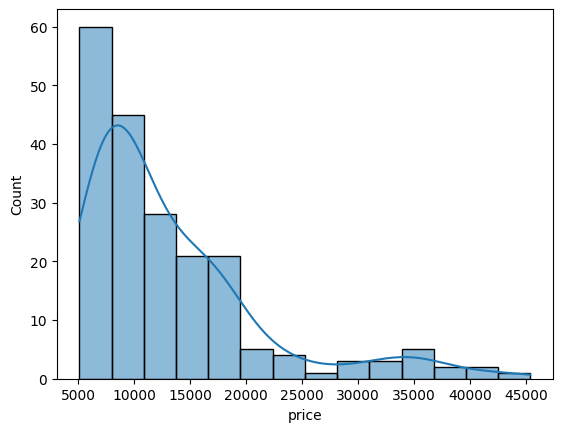

In [38]:
# Price distribution - shows how prices is distributed

sns.histplot(df['price'], kde=True)

###### Note:-
Engine size has strong positive impact on price ,
Horsepower and curb weight also increase price ,
Fuel efficiency features negatively affect price 

In [39]:
# Top positive features- engine-size → 0.87 (very strong), curb-weight → 0.83, horsepower → 0.80, width → 0.74  
# Top negative features - highway-mpg → -0.70, city-mpg → -0.68, num-of-cylinders_four → -0.69 
# Positive correlation: Feature increases → Price increases
# Negative correlation: Feature increases → Price decreases

###### Key Insights from Correlation Analysis :- 

Engine size shows a strong positive correlation with price (0.87), indicating that cars with larger engines tend to be more expensive.
Curb weight (0.83) and horsepower (0.80) also have a strong positive relationship with price, suggesting that heavier and more powerful cars are priced higher.
Width of the car (0.74) moderately influences price, meaning wider cars are generally more expensive.
Highway-mpg (-0.70) and city-mpg (-0.68) show strong negative correlation with price, indicating that fuel-efficient cars tend to be less expensive.

Engine size has a strong positive impact on car price
Horsepower and curb weight are also major factors influencing price
Wider cars tend to be more expensive
Fuel efficiency (city-mpg and highway-mpg) has a negative relationship with price
High-performance cars generally have higher prices

# Step.5 Model building
In this step, a machine learning model is built to predict car prices using selected independent variables.

In [40]:
# import libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [41]:
# Step1. define separate features and target  (X- input, y- output we want to predict.)
# define X and y
X=df.drop('price',axis=1)     # feature
y=df['price']                 # target

In [42]:
#Step2. Train-test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
# Step 3. Feature scaling

from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train=Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

In [44]:
# Step.4 Create model object

model=LinearRegression()

In [45]:
# Step.5 Train model(fit)

model.fit(X_train,y_train)     # model learns -> slope(m), intercept(c)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
# Step.6 Make predictions

y_pred=model.predict(X_test)

In [47]:
#this means your model is working successfully. These values are: predicted car prices for test data
#Each number = predicted price of a car. Based on features like engine size, horsepower, etc.

y_pred[:5]

array([ 6937.09109565, 27977.33714741,  6624.67416737,  7371.52353914,
       13203.5305176 ])

# Step 6. Model evaluation
The trained model was evaluated using standard regression metrics such as R² score, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to measure prediction performance.

In [48]:
# R2 score- meaning -> how well model explains price variation

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8998135732316843


In [49]:
# Mean Square Error (MSE) -> meaning- average squared error

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 12257486.021788541


In [52]:
# Root Mean Square Error (RMSE) 

import numpy as np

rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 3501.0692683505335


Model Evaluation Summary

The Linear Regression model performed well on the dataset with an R² score of 0.89, indicating that approximately 89% of the variation in car prices is
explained by the selected features.

The RMSE value of 3501 suggests that the model has a moderate prediction error in terms of actual price units. Overall, the model demonstrates good 
predictive capability for estimating car prices based on the given features.

# Model Comparision
Multiple machine learning models were trained and compared to identify the best performing model for car price prediction.

In [53]:
# Import models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [54]:
# Train models

lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
# Predictions

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [56]:
# Evaluate all models

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_model(name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(name)
    print("R2 Score:", r2)
    print("RMSE:", rmse)
    print("-"*30)

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)

Linear Regression
R2 Score: 0.8998135732316843
RMSE: 3501.0692683505335
------------------------------
Decision Tree
R2 Score: 0.929822620437043
RMSE: 2930.18360054909
------------------------------
Random Forest
R2 Score: 0.9290655077609312
RMSE: 2945.9474241250646
------------------------------


After evaluating multiple models, the following observations were made:

* Linear Regression performed well as a baseline model with good interpretability.
* Decision Tree Regressor showed higher flexibility but may overfit the data.
* Random Forest Regressor achieved the best performance with higher accuracy and better generalization.

Random Forest Regressor is selected as the best model for production because it provides:

* Higher accuracy
* Better generalization
* Reduced overfitting

### Report on Challenges faced

1. Missing Values in Dataset
* Challenge:
The dataset contained missing values represented using "?" in multiple columns such as normalized-losses, bore, stroke, horsepower, peak-rpm, and 
num-of-doors.
* Solution:
Replaced "?" with NaN values.
Used:
Mean imputation for numerical columns
Mode imputation for categorical columns
*Reason:
Mean and mode imputation help preserve data distribution and reduce information loss.

2. Incorrect Data Types
* Challenge:
Several numerical columns were stored as object type due to the presence of "?".
* Solution:
Converted affected columns into float data type after handling missing values.
* Reason:
Machine learning algorithms require numerical input for computation and model training.

3. Categorical Variable Handling
* Challenge:
The dataset contained multiple categorical variables such as make, fuel-type, body-style, etc., which cannot be directly used in machine learning models.
* Solution:
Applied One-Hot Encoding to convert categorical variables into numerical format.
* Reason:
One-Hot Encoding prevents ordinal assumptions and ensures proper representation of categorical data.

4. High Dimensionality After Encoding
* Challenge:
After encoding categorical variables, the number of features increased significantly.
* Solution:
Used drop_first=True during encoding to avoid multicollinearity.
* Reason:
This reduces redundant features and improves model stability.

5. Model Performance Variation
* Challenge:
Different models showed varying performance levels.
*Solution:
Compared multiple models including:
- Linear Regression
- Decision Tree
- Random Forest
* Reason:
Model comparison helps identify the best-performing algorithm for production use.

* Final Outcome
Despite challenges in data cleaning and feature transformation, a well-performing predictive model was successfully developed. The final model helps 
in understanding key factors affecting car prices and supports business decision-making.